# Module 2 — The Object-Oriented API: Core Fluency

This module is for building muscle memory. Module 1 covered what matplotlib is; this module focuses on how to actually draw with it.

By the end, the goal is to be able to produce a competent single-panel plot without looking much up.

## 1. The canonical workflow

Almost every matplotlib plot follows this five-step pattern:

```text
┌─────────────────────────────────────────────────────────┐
│ 1. Prepare data  → NumPy arrays / pandas                │
│ 2. Create fig+ax → fig, ax = plt.subplots()             │
│ 3. Draw          → ax.plot(), ax.scatter(), ...          │
│ 4. Customize     → ax.set_xlabel(), ax.legend(), ...     │
│ 5. Show or save  → plt.show() / fig.savefig()            │
└─────────────────────────────────────────────────────────┘
```

Most matplotlib questions reduce to identifying which `ax` method to call in step 3 or 4.

### Comparison with ggplot2

| ggplot2 | matplotlib |
|---|---|
| `ggplot(df, aes(x, y))` | `fig, ax = plt.subplots()`; data is passed per drawing call, not bound up front |
| `+ geom_point()` | `ax.scatter(x, y)` |
| `+ geom_line()` | `ax.plot(x, y)` |
| `+ labs(title = "...")` | `ax.set_title("...")` |
| `+ scale_y_log10()` | `ax.set_yscale("log")` |
| `print(p)` | `plt.show()` |
| `ggsave("out.png", p)` | `fig.savefig("out.png")` |

A subtle but important difference: in ggplot2, data is bound to the plot object once through `ggplot(df, ...)`. In matplotlib, data is passed every time a drawing method is called. There is no current dataset.

This can feel clunky at first, but it is flexible: different layers can come from completely different sources without requiring joins.

## 2. `plt.subplots()`: the default starting line

The standard starting point is:

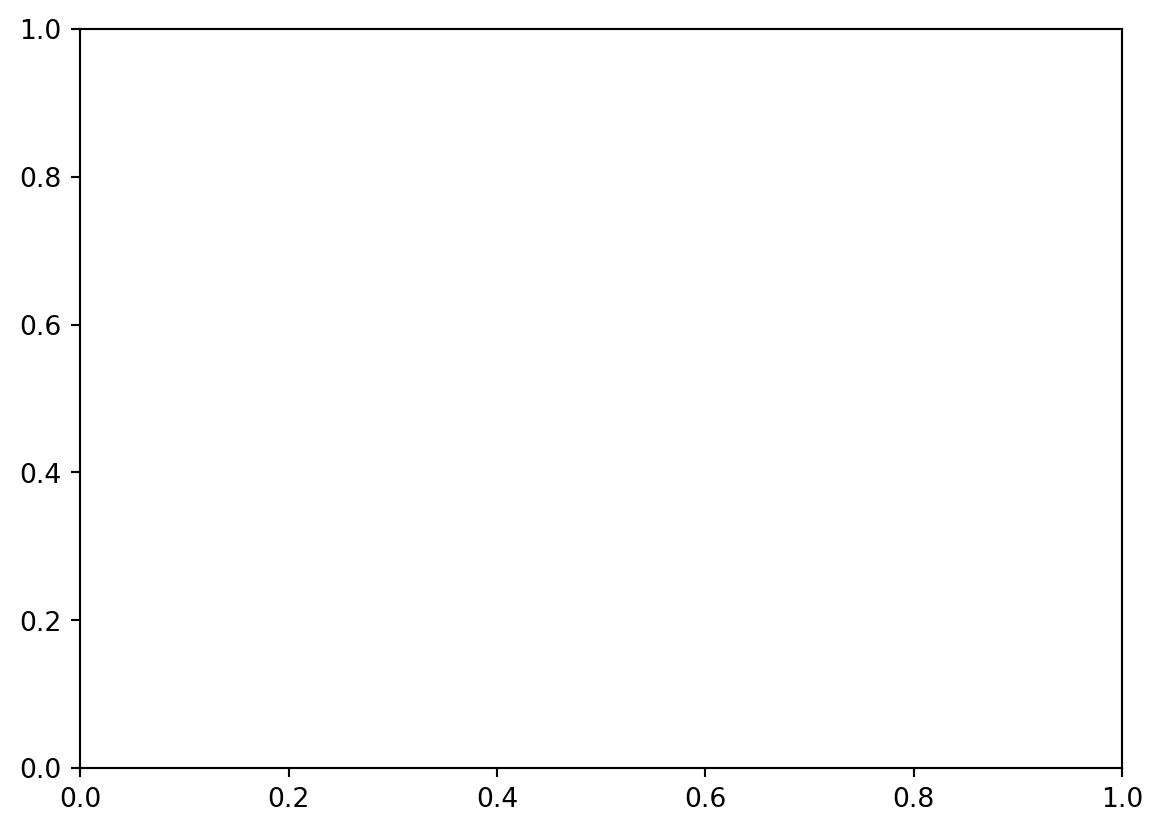

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

This creates one `Figure` and one `Axes` inside it.

Useful arguments that come up often:

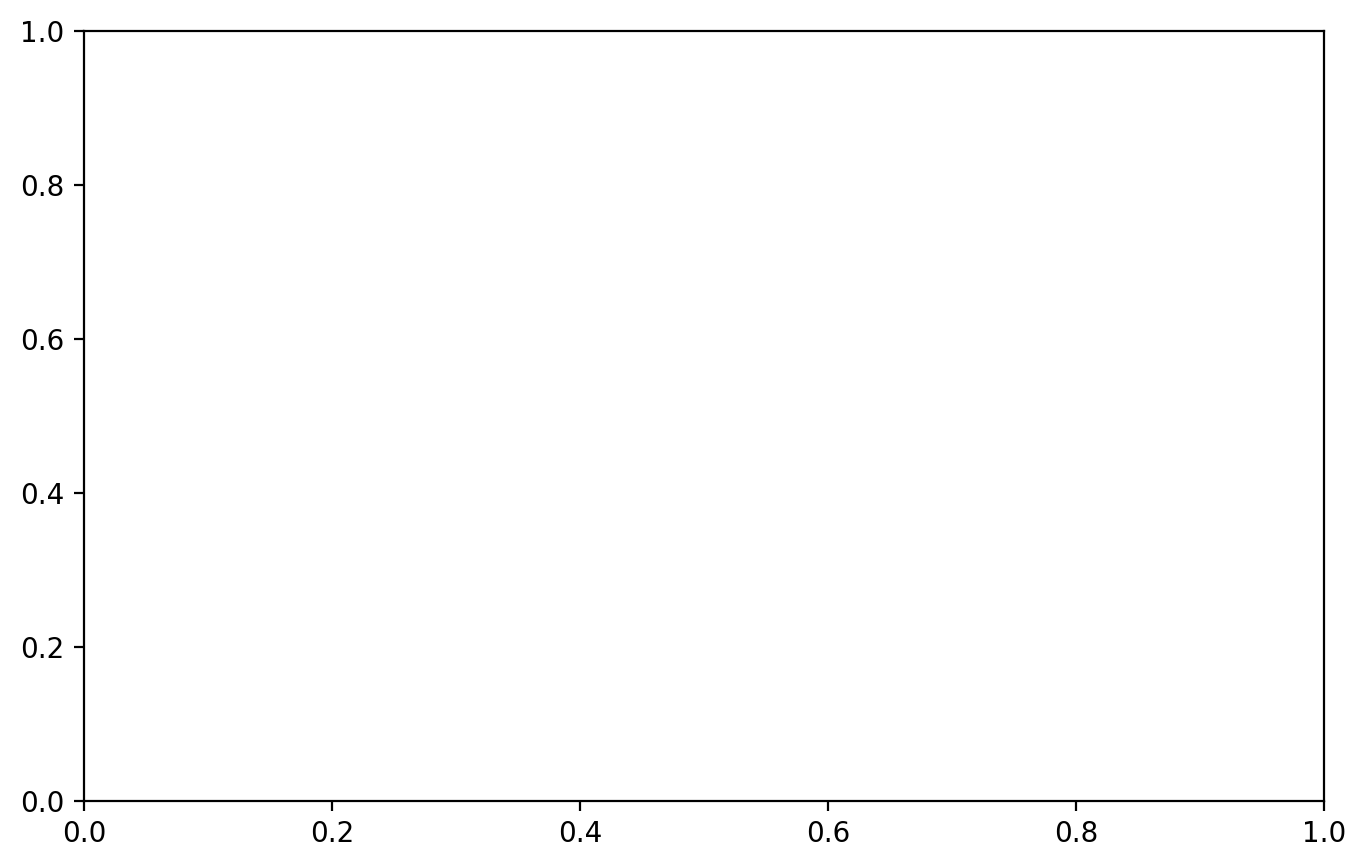

In [2]:
fig, ax = plt.subplots(
    figsize=(8, 5),  # width, height in inches, not pixels
    dpi=100,         # dots per inch; affects rendered pixel dimensions
)

`figsize` is in inches because matplotlib was designed with print output in mind. A figure with `figsize=(8, 5)` and `dpi=100` renders as 800×500 pixels.

For Quarto and journal figures, figure sizing in inches becomes important because it maps naturally to column widths. That belongs mostly in Module 10.

For multiple panels:

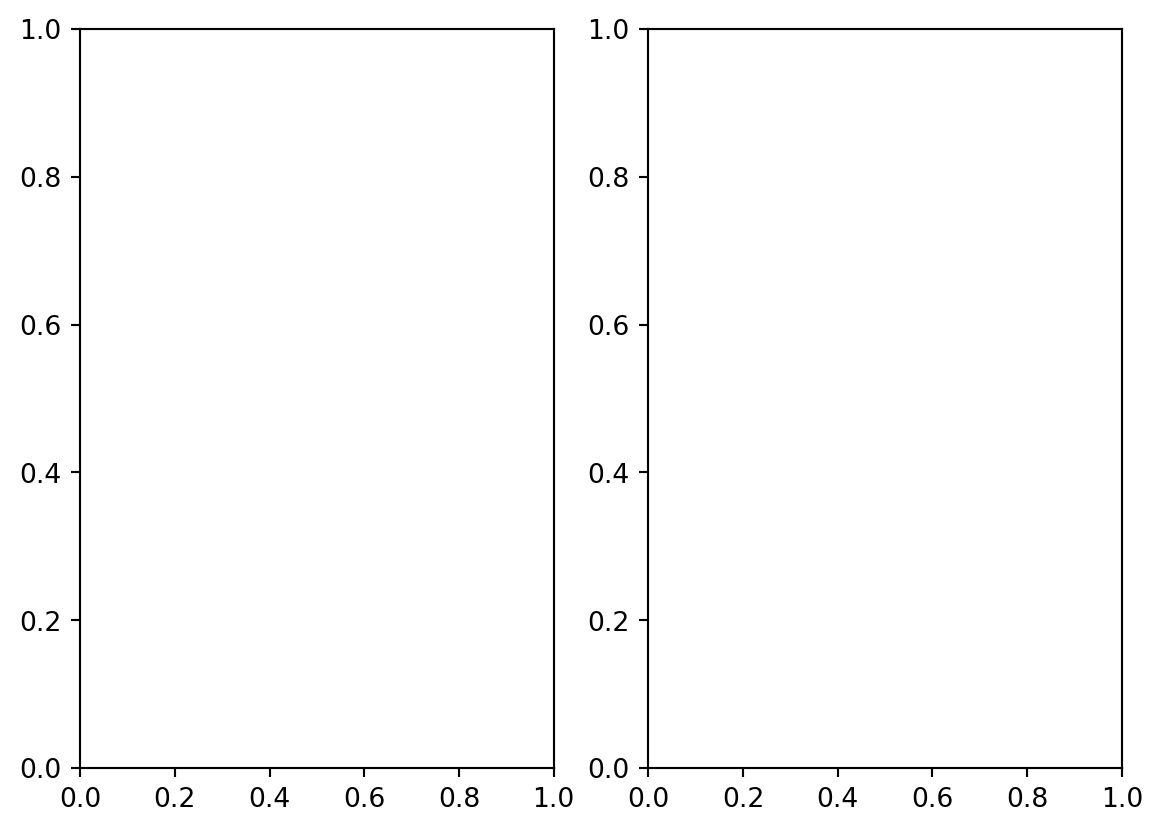

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=2)
ax_left, ax_right = axes

When there are multiple panels, `axes` is often a NumPy array of `Axes` objects. Naming it `axes` is a convention, not a rule.

## 3. Core drawing methods on `ax`

These are the verbs of matplotlib.

| Method | Use |
|---|---|
| `ax.plot(x, y)` | Line plot; connects points in order |
| `ax.scatter(x, y)` | Scatter plot; independent points |
| `ax.bar(x, heights)` | Vertical bars |
| `ax.barh(y, widths)` | Horizontal bars |
| `ax.hist(values)` | Histogram; bins and counts values |
| `ax.errorbar(x, y, yerr)` | Points or lines with error bars |
| `ax.fill_between(x, y1, y2)` | Shaded region between two curves |
| `ax.imshow(array_2d)` | Display a 2D array as an image |

A basic line plot:

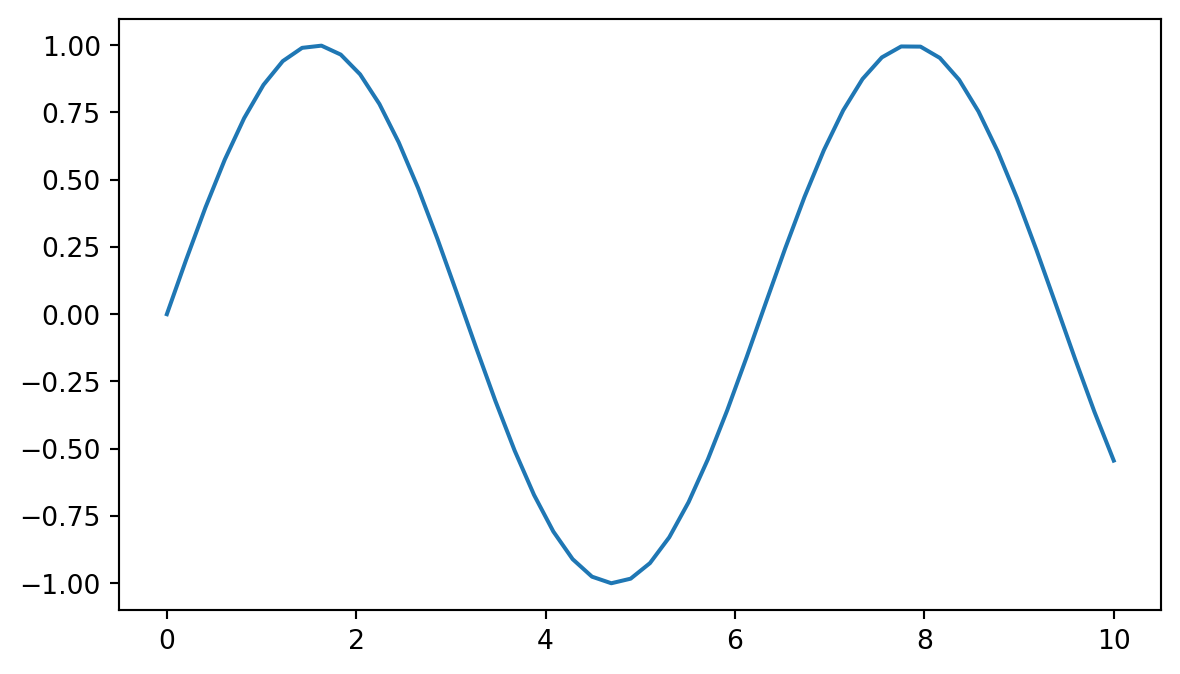

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 50)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y)
plt.show()

A scatter plot:

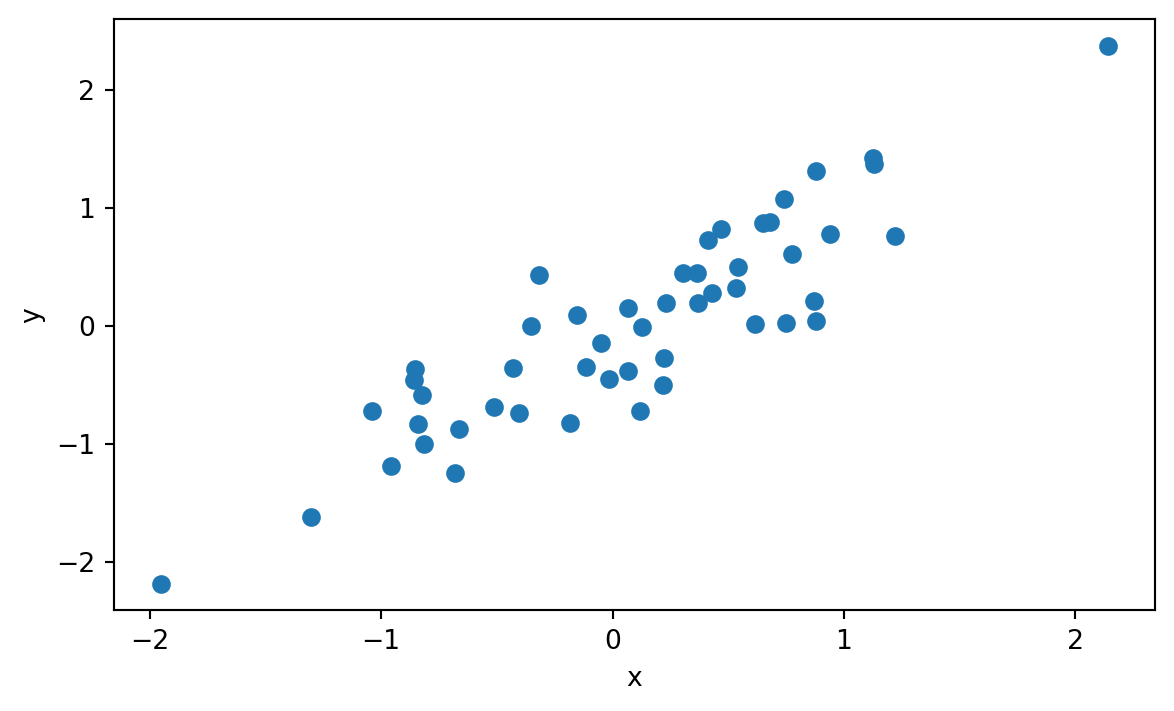

In [5]:
rng = np.random.default_rng(42)
x = rng.normal(size=50)
y = x + rng.normal(scale=0.5, size=50)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

Key intuition: `plot()` connects points in the order given. If the data are not sorted, `plot()` can produce spaghetti. `scatter()` does not care about order.

## 4. The `plot()` shorthand syntax

`ax.plot()` has a compact format string for quick styling:

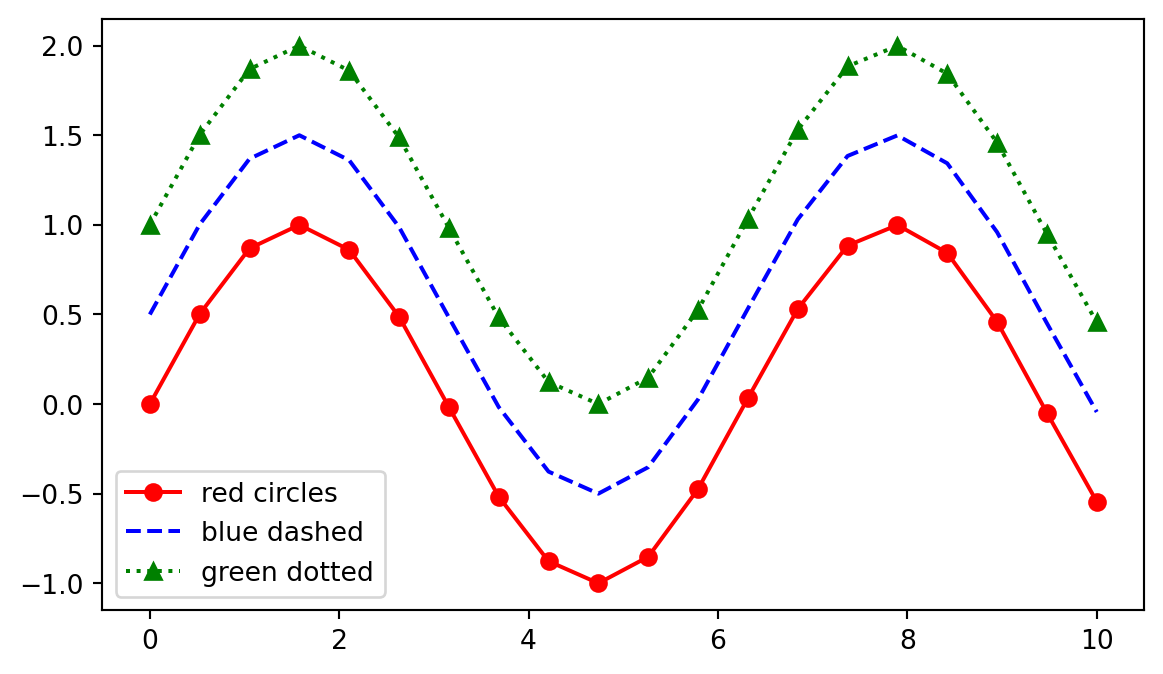

In [6]:
x = np.linspace(0, 10, 20)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, "ro-", label="red circles")      # red, circles, solid line
ax.plot(x, y + 0.5, "b--", label="blue dashed") # blue, dashed line, no markers
ax.plot(x, y + 1.0, "g^:", label="green dotted") # green, triangle markers, dotted line
ax.legend()
plt.show()

The format string is `[color][marker][linestyle]`, and each part is optional.

This shorthand is useful for exploration, but explicit keyword arguments are clearer for serious code:

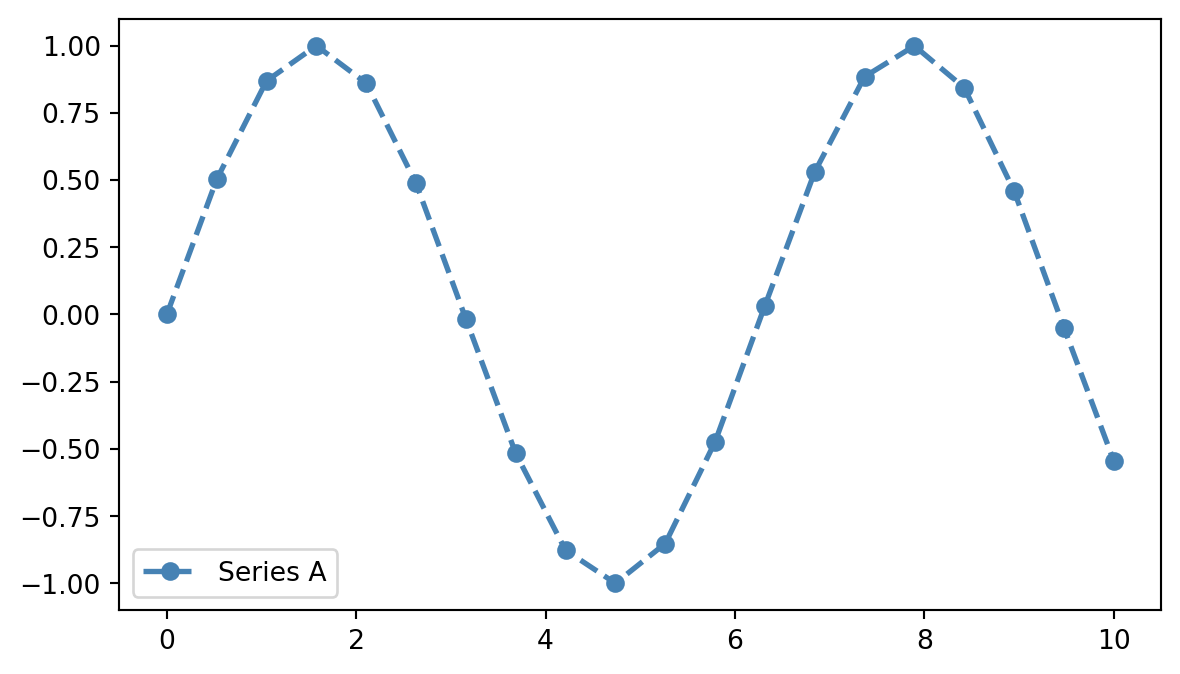

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    x,
    y,
    color="steelblue",
    marker="o",
    linestyle="--",
    linewidth=2,
    markersize=6,
    label="Series A",
)
ax.legend()
plt.show()

Explicit keywords are more readable and easier to discover through editor autocomplete. Treat the compact format string like a useful shortcut for quick work, not the default for code that others will read.

## 5. Layering: multiple draw calls on the same `ax`

Layering in matplotlib means making multiple drawing calls on the same `Axes`. Each call adds another visible layer, in the order called.

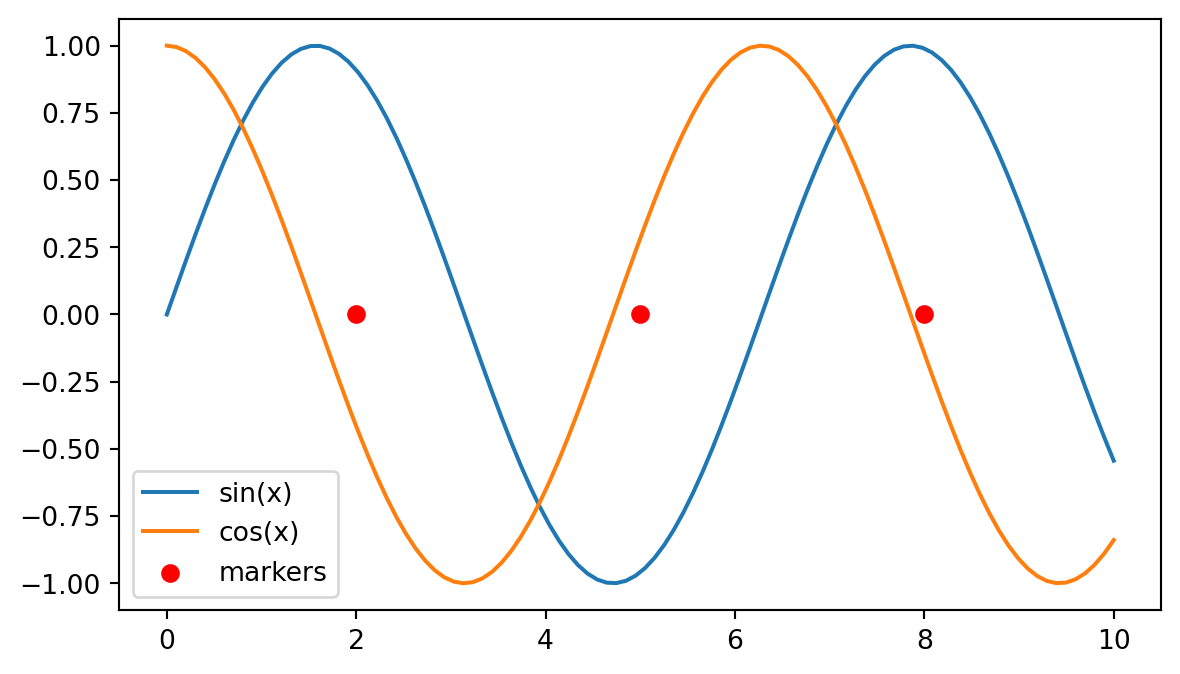

In [8]:
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.scatter([2, 5, 8], [0, 0, 0], color="red", zorder=3, label="markers")
ax.legend()
plt.show()

The closest ggplot2 analogy is layer composition:

| ggplot2 | matplotlib |
|---|---|
| `ggplot(df) +` | `fig, ax = plt.subplots()` |
| `geom_line(aes(x, sin_x)) +` | `ax.plot(x, sin_x)` |
| `geom_line(aes(x, cos_x)) +` | `ax.plot(x, cos_x)` |
| `geom_point(data = pts, ...)` | `ax.scatter(...)` |

The `zorder` keyword controls draw order. Higher values are drawn on top. Most of the time, simply call layers in the order you want them stacked.

## 6. Passing data: NumPy arrays and pandas Series

Matplotlib accepts anything array-like: lists, NumPy arrays, pandas Series, and tuples.

### NumPy style

This is common when generating or computing data:

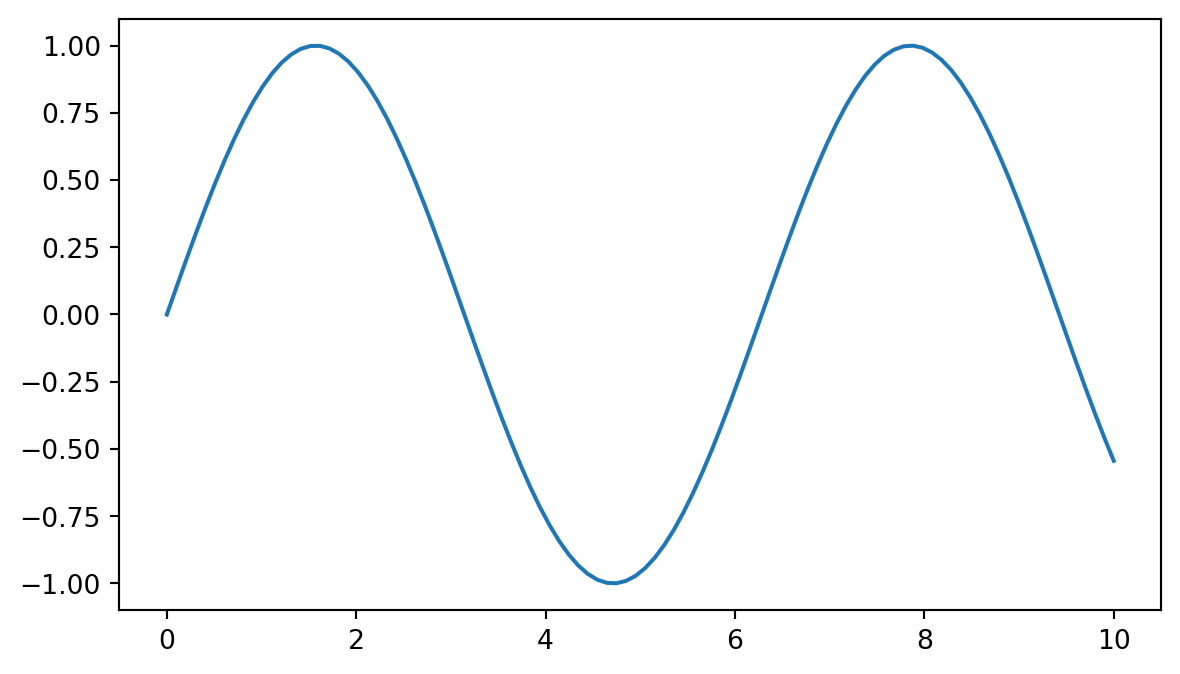

In [9]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y)
plt.show()

### Pandas style

This is common when working with a `DataFrame`:

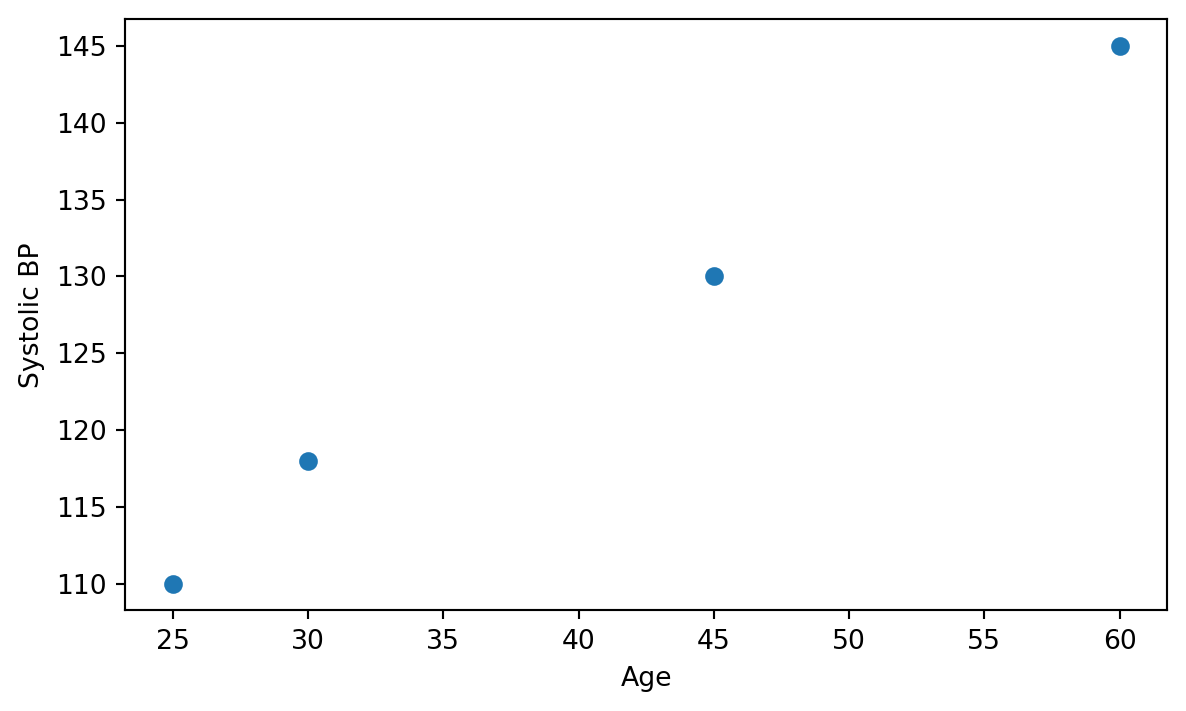

In [10]:
import pandas as pd

df = pd.DataFrame({"age": [25, 30, 45, 60], "bp": [110, 118, 130, 145]})

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df["age"], df["bp"])
ax.set_xlabel("Age")
ax.set_ylabel("Systolic BP")
plt.show()

Matplotlib also supports a `data=` form that is closer to the ggplot2 mental model:

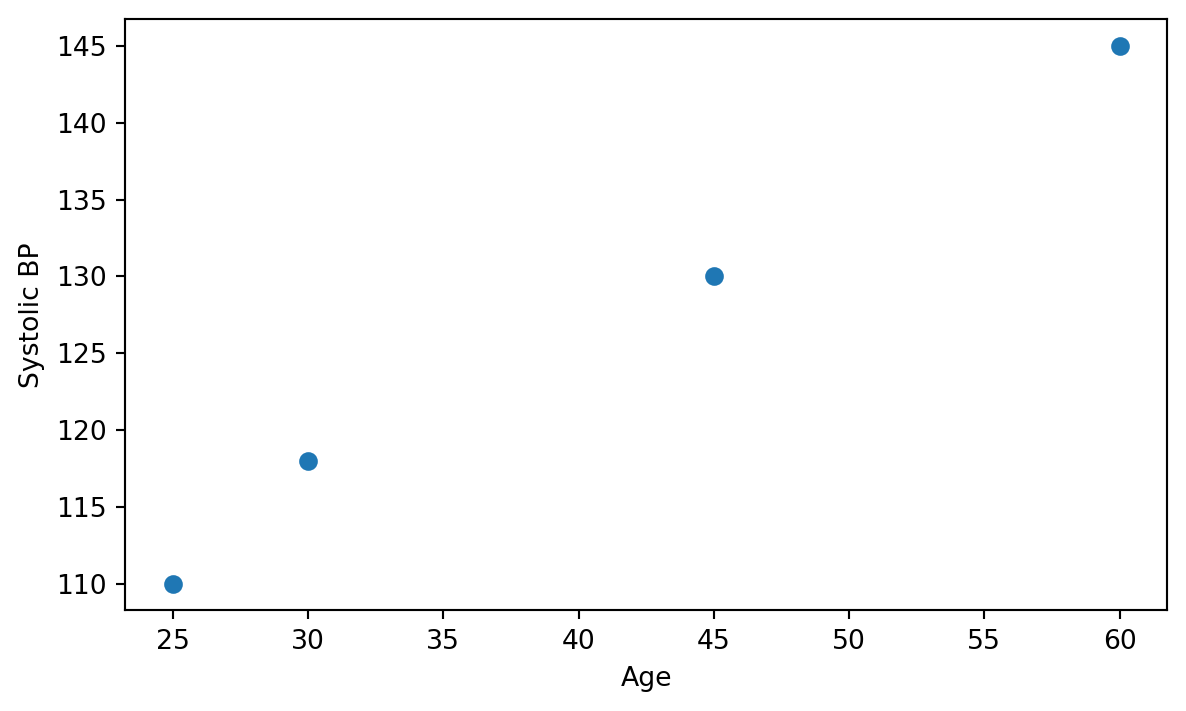

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x="age", y="bp", data=df)
ax.set_xlabel("Age")
ax.set_ylabel("Systolic BP")
plt.show()

The `data=` form is worth knowing, but many matplotlib users pass `df["col"]` directly because it is explicit and works naturally with expressions.

## 7. The basic customization quartet

These four customizations appear in nearly every plot:

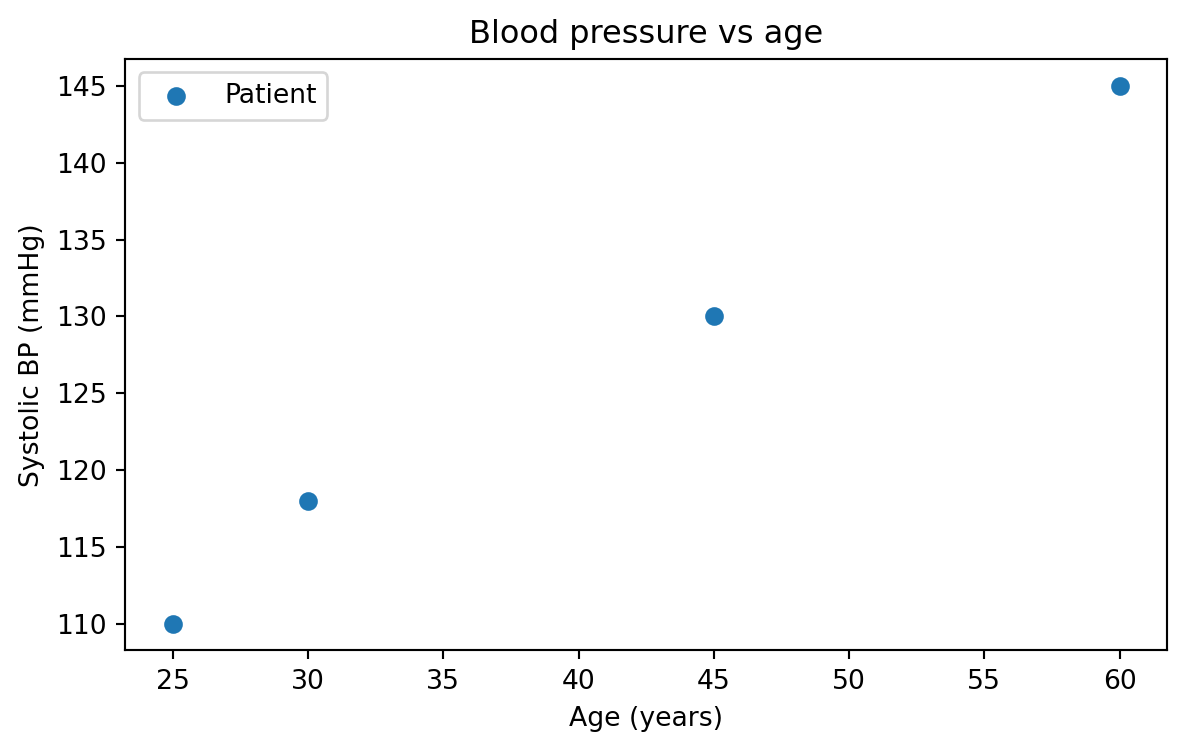

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x="age", y="bp", data=df, label="Patient")
ax.set_title("Blood pressure vs age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Systolic BP (mmHg)")
ax.legend()
plt.show()

There is also a one-shot helper that sets several properties at once:

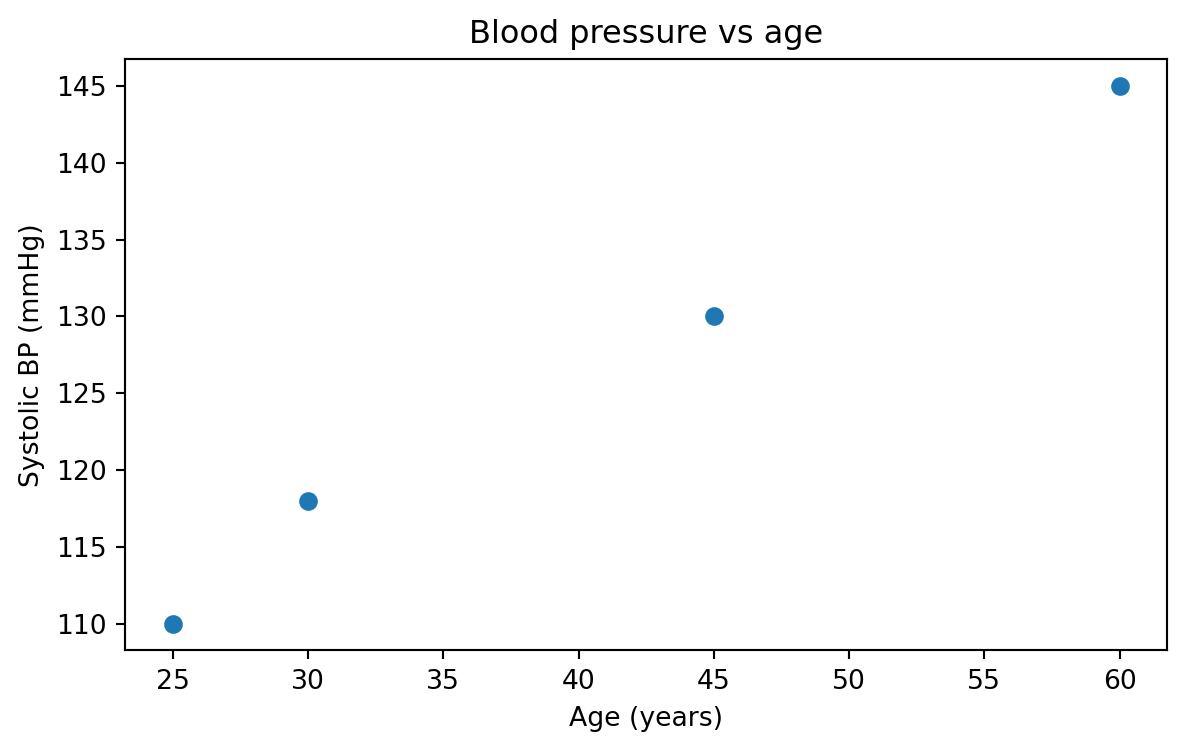

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x="age", y="bp", data=df)
ax.set(
    title="Blood pressure vs age",
    xlabel="Age (years)",
    ylabel="Systolic BP (mmHg)",
)
plt.show()

The `ax.set(...)` style is compact, though individual methods are often easier to autocomplete. Either style is fine.

## 8. A complete radiology-flavored example

This example simulates AI model confidence versus lesion size, split by reader group.

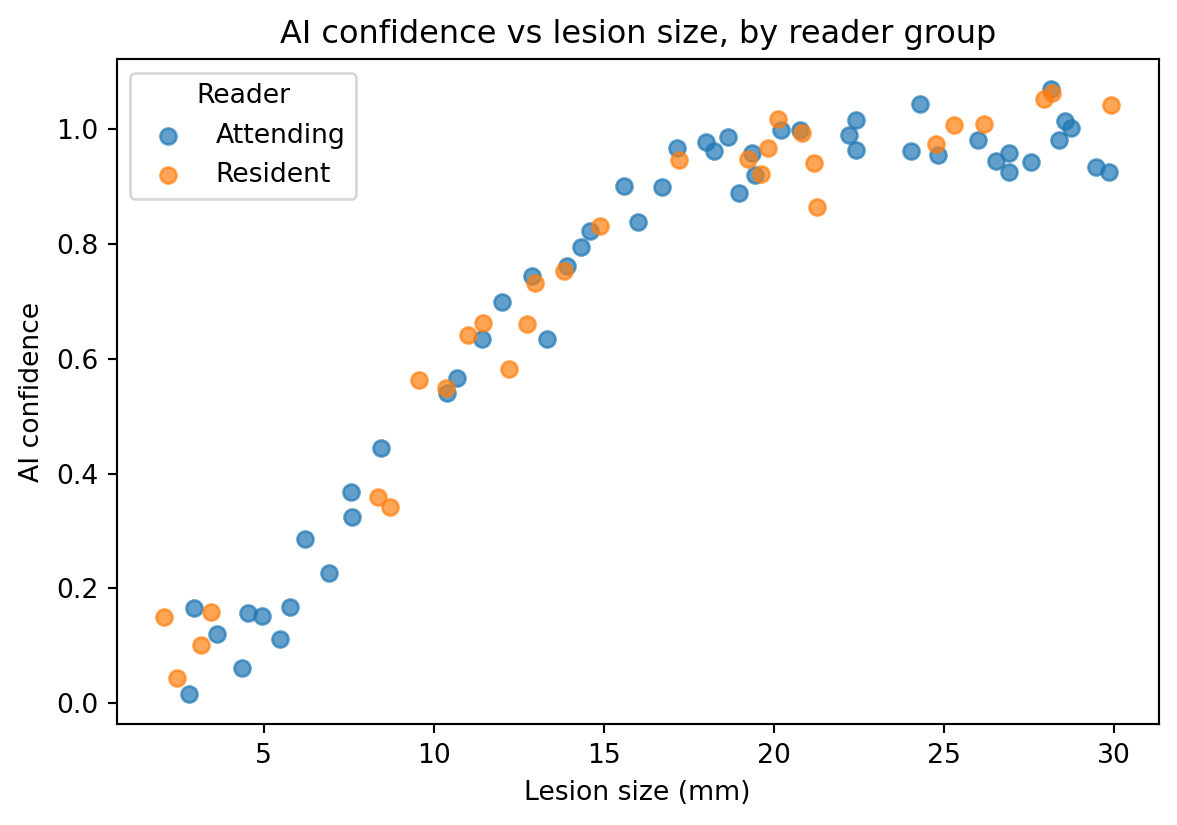

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Simulated: AI model confidence vs lesion size, two reader groups
rng = np.random.default_rng(0)
size_mm = rng.uniform(2, 30, 80)
confidence = 1 / (1 + np.exp(-(size_mm - 10) / 3)) + rng.normal(0, 0.05, 80)
group = rng.choice(["Resident", "Attending"], size=80)
df = pd.DataFrame({"size_mm": size_mm, "confidence": confidence, "group": group})

# Step 2: create fig + ax
fig, ax = plt.subplots(figsize=(7, 4.5))

# Step 3: draw one scatter layer per group
for name, sub in df.groupby("group"):
    ax.scatter(
        sub["size_mm"],
        sub["confidence"],
        label=name,
        alpha=0.7,
    )

# Step 4: customize
ax.set_xlabel("Lesion size (mm)")
ax.set_ylabel("AI confidence")
ax.set_title("AI confidence vs lesion size, by reader group")
ax.legend(title="Reader")

# Step 5: show
plt.show()

The `for name, sub in df.groupby("group")` loop is the matplotlib equivalent of a color aesthetic such as `aes(color = group)` in ggplot2.

Matplotlib does not automatically map a categorical column to colors in the same way ggplot2 does. Drawing one layer per group is more verbose, but it provides full control. Seaborn handles this mapping automatically, which is one reason it is useful.

## Exercises

These exercises are meant to lock in the five-step workflow.

### Exercise 1

Plot `y = x²` for `x` from -5 to 5 using 100 points. Add a title, x-label, and y-label. Use `np.linspace`.

### Exercise 2

On the same `ax`, plot both `y = sin(x)` and `y = cos(x)` for `x` from 0 to `2π`. Give each line a `label=` and call `ax.legend()`.

### Exercise 3

Make a scatter plot of 100 random points where `x ~ Normal(0, 1)` and `y = 2x + noise`. Style the markers as red triangles with 50% transparency using `alpha=0.5`.

### Exercise 4

Start with this small DataFrame:

```python
df = pd.DataFrame({
    "modality": ["CT", "MRI", "US", "XR"],
    "studies": [1240, 890, 2100, 3400],
})
```

Make a bar chart of studies per modality.

Hint:

```python
ax.bar(df["modality"], df["studies"])
```